Auteur : Gabriel Casarotto

Projet : Projet Master IPSA (PMI) - Mission Aragosat-1

Objectif : Modélisation 0D du propulseur ionique NGIT-1

Date : 1 Janvier 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import e, m_e, epsilon_0, k, h, g
import sys # Pour la gestion de la sortie

# =================================================================
# 1. CONSTANTES PHYSIQUES (MKS)
# =================================================================
CONST = {
    'e': e,                     # C, Charge élémentaire
    'eps0': epsilon_0,          # F/m, Permittivité du vide
    'kB': k,                    # J/K, Constante de Boltzmann
    'g0': g,                    # m/s², Accélération de la gravité
    'amu': 1.66054e-27,         # kg, Unité de masse atomique
    # Masse du Krypton (Kr - A~83.8)
    'm_Kr': 83.798 * 1.66054e-27,  # kg
}

In [2]:
class GITGlobalModel:
    """
    Modèle 0D (Global) Statique pour GIT, version simplifiée.
    - On ne s'intéresse pas à la décharge (pas de V_discharge, I_discharge).
    - Le plasma est supposé déjà formé.
    - On se concentre sur le faisceau (V_beam) et le débit massique.
    """
    
    def __init__(self,
                 # Constantes physiques
                 C=CONST,
                 # Géométrie chambre
                 L_chamber=0.08,           # m - Longueur chambre
                 A_chamber=1e-3,           # m² - Section chambre
                 # Propergol (Krypton)
                 mass_flow=2e-6,           # kg/s - Débit massique (m_dot)
                 T_neutrals=500,           # K - Température neutres
                 # Grilles (accélération)
                 V_beam=800.0,            # V - Tension faisceau
                 d_grids=1.2e-3,           # m - Espacement grilles
                 tau_optical=0.65,         # - Transparence optique grilles (tau)
                 # Physique (simplifiée)
                 Te_eV=5.0,                # eV - Température électronique (fixée)
                 ki_coeff=1e-14,         # m³/s - Coeff. ionisation (fixé)
                 P_discharge = 5         # W - Puissance de décharge 
                ):

        self.C = C
        self.m_i = self.C['m_Kr']
        
        # 1. Paramètres d'entrée
        self.L = L_chamber
        self.A = A_chamber
        self.V_ch = L_chamber * A_chamber
        self.mass_flow = mass_flow
        self.T_neutrals = T_neutrals
        self.Te_eV = Te_eV
        self.ki = ki_coeff
        self.lambda_i = 0.03  # m - ion-neutral mean free path
        
        # 2. Paramètres "faisceau"
        self.V_beam = V_beam
        self.d_grids = d_grids
        self.tau = tau_optical
        
        self.P_discharge = P_discharge
        
        # 3. Calculs préliminaires fixes
        
        # Vitesse de Bohm (Débit de perte)
        self.u_B = np.sqrt(self.C['e'] * self.Te_eV / self.m_i)
        
        # Vitesse Thermique Neutre (pour flux entrant/sortant)
        self.v_neutrals = np.sqrt(8 * self.C['kB'] * self.T_neutrals / (np.pi * self.m_i))
        
        # Aire effective de perte aux parois (A_eff_wall)
        # Rayon de la chambre (cylindre)
        self.R = np.sqrt(self.A / np.pi)

        # --- Edge-to-center ratios Goebel & Katz ---
        # h_L = 0.86 (3 + L / (2 λ_i))^{-1/2}
        # h_R = 0.8  (4 + R / λ_i)^{-1/2}
        self.h_L = 0.86 * (3.0 + self.L / (2.0 * self.lambda_i))**(-0.5)
        self.h_R = 0.8  * (4.0 + self.R / self.lambda_i)**(-0.5)

        # Aire effective de perte aux parois (A_eff) – Eq. (6)
        # A_eff = 2 h_R π R L + 2 h_L π R^2
        self.A_eff_wall = 2.0 * self.h_R * np.pi * self.R * self.L + 2.0 * self.h_L * np.pi * self.R**2

        # Fréquence de perte volumique aux parois (nu_loss_vol)
        self.nu_loss_vol = (self.u_B * self.A_eff_wall) / self.V_ch
                
        # Flux de particules neutres entrant total (particules/s)
        self.N_dot_neutral = self.mass_flow / self.m_i
        
        # Courant limite Child-Langmuir I_CL
        self.I_CL = self._calculate_I_CL()
        
        # 4. Initialisation des résultats
        self.n_i = 0.0
        self.n_a = 0.0
        self.I_beam = 0.0
        self.eta_mass = 0.0
        self.I_wall_loss = 0.0
        self.I_plasma_available = 0.0
        self.fluxes = {}
        
        print(f"✓ Modèle 0D (Krypton) initialisé. T_e fixé à {self.Te_eV} eV.")

    def _calculate_I_CL(self):
        """
        Calcule le courant limite Child-Langmuir I_CL.
        """
        J_CL = (4/9) * self.C['eps0'] * np.sqrt(2 * self.C['e'] / self.m_i) * \
               (self.V_beam ** 1.5) / (self.d_grids ** 2)
        
        I_CL = J_CL * self.A * self.tau
        return I_CL
    
    def solve_equations(self):
        """
        Résolution statique du modèle 0D (sans "sécurité") :
        - n_a est pris exactement à l'équilibre (nu_iz = nu_loss_vol),
        - on calcule les rendements de masse (total et faisceau) à partir des bilans de particules.
        """
        print("\n--- Résolution Statique (Modèle simplifié sans décharge) ---")
        
        # --- 1. Densité neutre d'équilibre ---
        # nu_iz = ki * n_a ; on impose nu_iz = nu_loss_vol  ->  n_a = nu_loss_vol / ki
        n_a_eq = self.nu_loss_vol / self.ki
        self.n_a = n_a_eq  # plus de 1.1 * n_a_eq

        # --- 2. Densité ionique
        self.n_i = self.n_a * 0.01  # On fixe n_i à 1% de n_a pour garantir une ionisation suffisante
        
        # --- 3. Courants disponibles et extraits ---
        self.I_plasma_available = self.C['e'] * self.n_i * self.u_B * self.A
        self.I_wall_loss        = self.C['e'] * self.n_i * self.u_B * self.A_eff_wall

        # Le courant de faisceau est limité soit par Child-Langmuir, soit par la production
        self.I_beam = min(self.I_CL, self.I_plasma_available * self.tau)

        # --- 4. Bilans de particules et rendements de masse ---
        self.N_dot_beam = self.I_beam / self.C['e']
        self.N_dot_wall = self.I_wall_loss / self.C['e']

        print("✓ Résolution Statique terminée.")
        print(f"  n_a utilisé                : {self.n_a:.2e} m⁻³")
        print(f"  n_i obtenu                 : {self.n_i:.2e} m⁻³")

        
    def compute_and_print_performances(self):
        """
        Calcule et affiche les performances finales (Poussée, Isp, etc.)
        dans la version simplifiée : seule la puissance de faisceau est considérée.
        """
        if self.I_beam == 0.0:
            print("\n❌ Impossible de calculer les performances : Courant de faisceau nul.")
            return
        
        v_beam = np.sqrt(2 * self.C['e'] * self.V_beam / self.m_i) # vitesse faisceau ionique
        T_thrust = self.I_beam * self.m_i * v_beam / self.C['e'] # Poussée totale
        Isp_global = T_thrust / (self.mass_flow * self.C['g0']) # Faible résultat car inclu les neutres non accélérés
        Isp_beam = v_beam / self.C['g0']  # Isp basé uniquement sur le faisceau ionique
        
        P_beam = self.I_beam * self.V_beam
        P_jet = 0.5 * T_thrust* v_beam
        P_total = P_beam + self.P_discharge
        eta_elec = P_jet / P_total if P_total > 0 else 0.0
            
        # Rendement de masse total : tous les ions (beam + parois)
        self.eta_mass_total = (self.N_dot_beam + self.N_dot_wall) / self.N_dot_neutral

        # Rendement de masse utile faisceau : uniquement les ions qui contribuent à la poussée
        self.eta_mass_beam  = self.N_dot_beam / self.N_dot_neutral
        
        # print("Pjet :", P_jet, "Pbeam:", P_beam) On trouve que P_jet ~ P_beam

        print("\n=======================================================")
        print("=== RÉSULTATS DU MODÈLE GLOBAL 0D SIMPLIFIÉ (GIT) ===")
        print("=======================================================")
        print(f"  ▶ Densité Neutre (n_a)  : {self.n_a:.2e} m⁻³")
        print(f"  ▶ Densité Ionique (n_i) : {self.n_i:.2e} m⁻³")
        print("-------------------------------------------------------")
        print(f"  ▶ Débit Massique (ṁ)                : {self.mass_flow*1e6:.2f} mg/s")
        print(f"  ▶ Courant de Faisceau (I_beam)      : {self.I_beam*1e3:.2f} mA")
        print(f"  ▶ Poussée (T)                       : {T_thrust*1e3:.2f} mN")
        print(f"  ▶ Impulsion Spécifique (Isp_global) : {Isp_global:.1f} s (inclut neutres non accélérés)")
        print(f"  ▶ Impulsion Spécifique (Isp_beam)   : {Isp_beam:.1f} s (faisceau ions uniquement)")
        print("-------------------------------------------------------")
        print(f"  ▶ Puissance Faisceau (P_beam)  : {P_beam:.1f} W")
        print(f"  ▶ Puissance Totale (P_total)   : {P_total:.1f} W")
        print("-------------------------------------------------------")
        print(f"  ▶ Rendement Total (η_elec)     : {eta_elec*100:.2f} %")
        print(f"  ▶ η_mass (total ions)          : {self.eta_mass_total*100:.2f} % (inclut pertes parois)")
        print(f"  ▶ η_ion (faisceau utile)       : {self.eta_mass_beam*100:.2f} % (faisceau ions uniquement)")
        print(f"  ▶ Vitesse faisceau (v_beam)    : {v_beam/1e3:.2f} km/s")
        print("=======================================================")
        print(f"\n--- Facteurs limitant l'extraction ---")
        print(f"  I_CL (Limite Child-Langmuir) : {self.I_CL*1e3:.2f} mA")
        print(f"  I_plasma (Disponible)        : {self.I_plasma_available*1e3:.2f} mA")
        print(f"  I_wall (Pertes par parois)   : {self.I_wall_loss*1e3:.2f} mA")
        
        limit_factor = 'Production (I_plasma)'
        if self.I_CL < self.I_plasma_available * self.tau:
            limit_factor = 'Extraction (I_CL)'
        print(f"  Facteur limitant réel        : {limit_factor}")
        
        # frequ_iz_s_1 = self.ki * self.n_a
        # frequ_loss_vol_s_1 = self.nu_loss_vol
        # print(f"\n--- Fréquences caractéristiques ---")
        # print(f"  Fréquence Ionisation (ν_iz)          : {frequ_iz_s_1:.2e} s⁻¹")
        # print(f"  Fréquence Perte Parois (ν_loss, vol) : {frequ_loss_vol_s_1:.2e} s⁻¹")
        

- η_mass : c'est la proportion du débit massique total de propergol injecté qui a été convertie en ions (ionisée), qu'ils finissent dans le faisceau ou qu'ils soient perdus sur les parois (pertes Bohm). Cela signifie que 20.16 % du gaz injecté a été ionisé pour former le plasma.
- η_ion : seulement 2.72 % de la masse de Krypton injectée sert réellement à produire la poussée. 
- η_elec : conversion Électricité fournie → Énergie cinétique utile du jet.

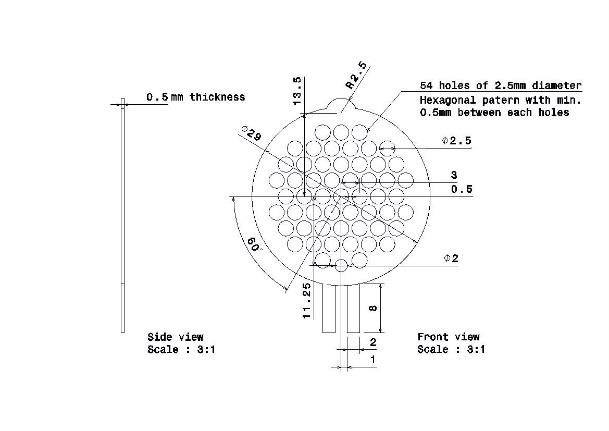

In [3]:
# --- 1. Instanciation du modèle ---
# On utilise vos paramètres initiaux.
git_0d = GITGlobalModel(
    L_chamber=0.08, 
    A_chamber=1e-3, 
    mass_flow=1e-6,           # Débit massique (ṁ)
    V_beam=800.0, 
    d_grids=1.2e-3, 
    tau_optical=0.65,
    Te_eV=5.0,                # Température électronique (Te)
    ki_coeff=1e-14,           # Coefficient d'ionisation
    P_discharge=5         # W - Puissance de décharge
)

# --- 2. Résolution du modèle 0D ---
git_0d.solve_equations() 

# --- 3. Calcul et affichage des performances ---
git_0d.compute_and_print_performances()

✓ Modèle 0D (Krypton) initialisé. T_e fixé à 5.0 eV.

--- Résolution Statique (Modèle simplifié sans décharge) ---
✓ Résolution Statique terminée.
  n_a utilisé                : 1.25e+19 m⁻³
  n_i obtenu                 : 1.25e+17 m⁻³

=== RÉSULTATS DU MODÈLE GLOBAL 0D SIMPLIFIÉ (GIT) ===
  ▶ Densité Neutre (n_a)  : 1.25e+19 m⁻³
  ▶ Densité Ionique (n_i) : 1.25e+17 m⁻³
-------------------------------------------------------
  ▶ Débit Massique (ṁ)                : 1.00 mg/s
  ▶ Courant de Faisceau (I_beam)      : 31.28 mA
  ▶ Poussée (T)                       : 1.17 mN
  ▶ Impulsion Spécifique (Isp_global) : 118.9 s (inclut neutres non accélérés)
  ▶ Impulsion Spécifique (Isp_beam)   : 4376.8 s (faisceau ions uniquement)
-------------------------------------------------------
  ▶ Puissance Faisceau (P_beam)  : 25.0 W
  ▶ Puissance Totale (P_total)   : 30.0 W
-------------------------------------------------------
  ▶ Rendement Total (η_elec)     : 83.34 %
  ▶ η_mass (total ions)       

Pour obtenir un meilleur rendement ionique, on peut réduire le débit massique -> réduire na​. On réduit la fraction d'utilisation du propergol


=== RÉSULTATS GRAPHIQUES DU MODÈLE GLOBAL 0D (GIT) ===


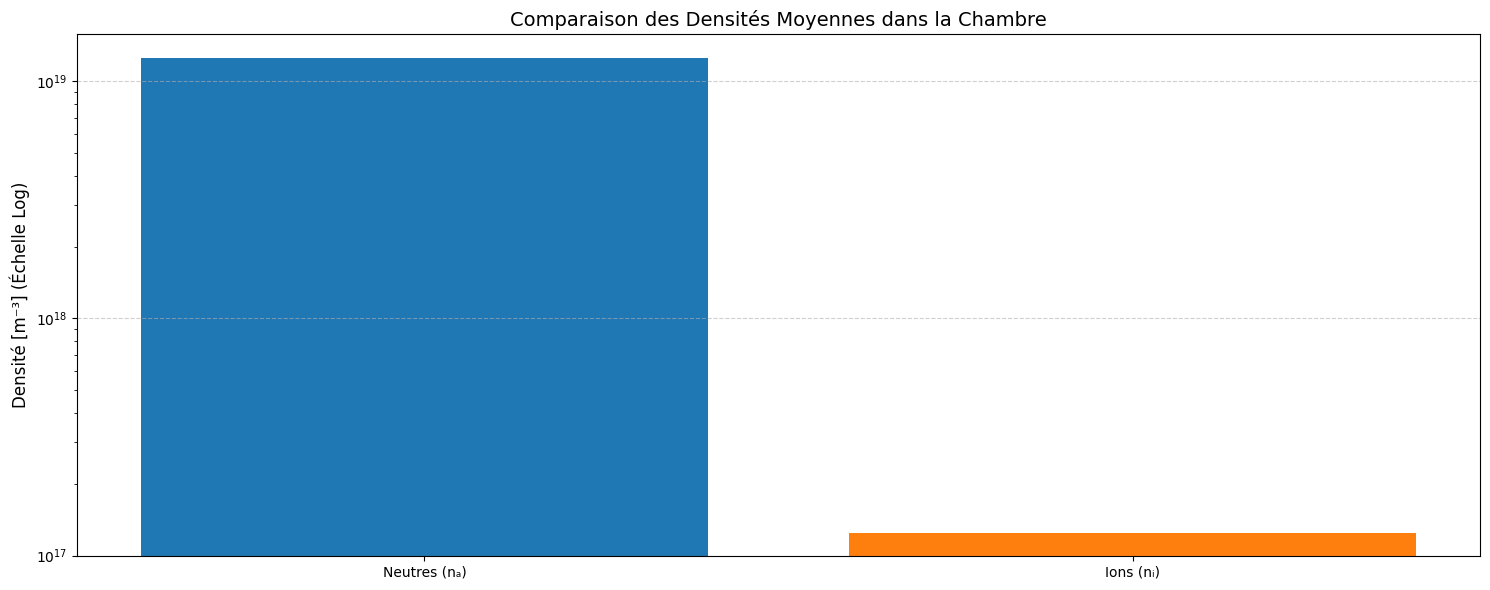

  ▶ Densité Neutre (n_a)  : 1.25e+19 m⁻³
  ▶ Densité Ionique (n_i) : 1.25e+17 m⁻³


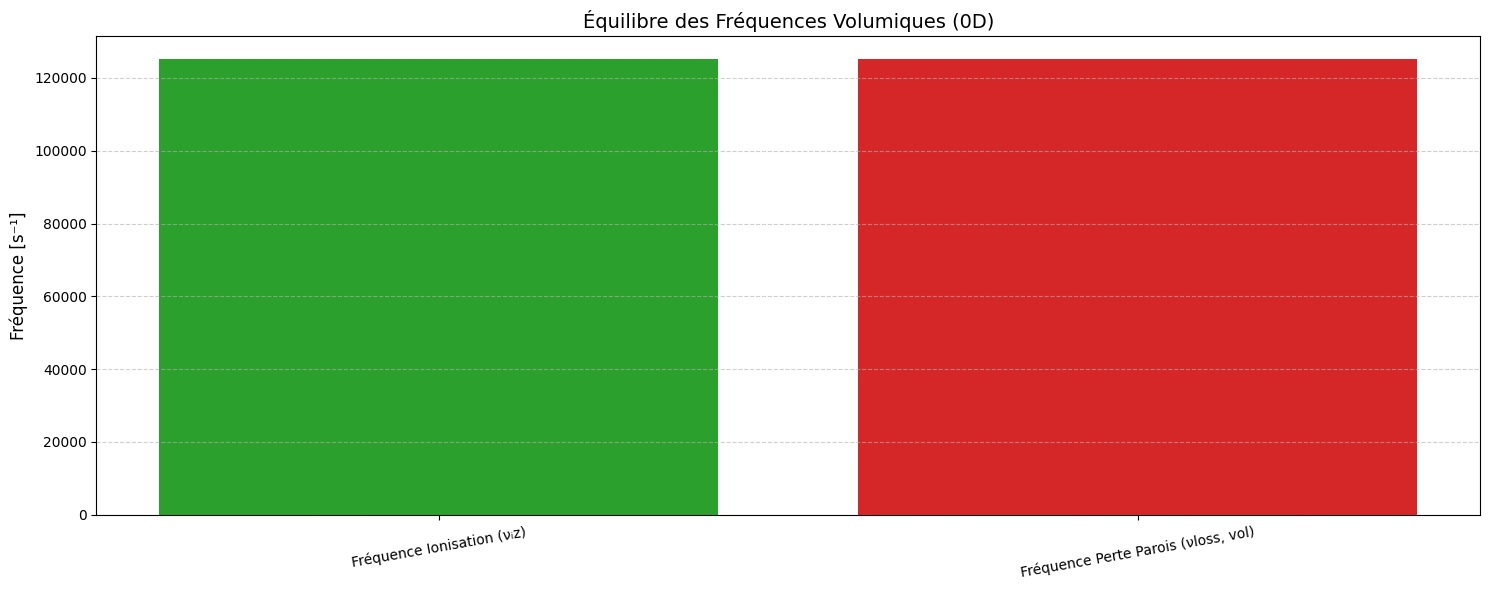

  ▶ Fréquence Ionisation (νᵢz)          : 1.25e+05 s⁻¹
  ▶ Fréquence Perte Parois (νloss, vol) : 1.25e+05 s⁻¹


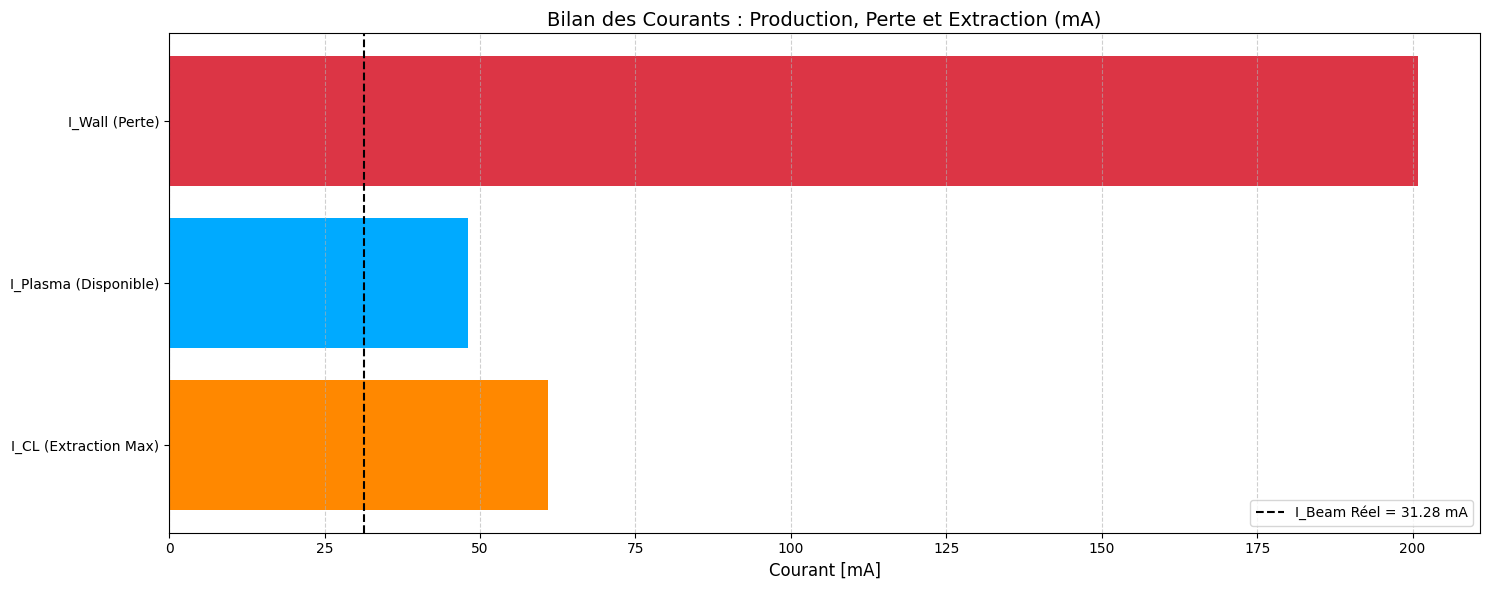

In [4]:
# --- Récupération des données pour le plotting ---

# Courants
I_CL_mA = git_0d.I_CL * 1e3
I_plasma_available_mA = git_0d.I_plasma_available * 1e3
I_wall_mA = git_0d.I_wall_loss * 1e3
I_beam_mA = git_0d.I_beam * 1e3

# Fréquences
nu_iz_s_1 = git_0d.ki * git_0d.n_a
nu_loss_vol_s_1 = git_0d.nu_loss_vol

# Densités
n_a = git_0d.n_a
n_i = git_0d.n_i
labels_dens = ['Neutres (nₐ)', 'Ions (nᵢ)']
values_dens = [n_a, n_i]

# --- Affichage des résultats numériques (Optionnel, mais utile) ---
print("\n=======================================================")
print("=== RÉSULTATS GRAPHIQUES DU MODÈLE GLOBAL 0D (GIT) ===")
print("=======================================================")

# ==========================================================
# Graphique 1 : Densités (n_i vs n_a)
# ==========================================================
plt.figure(figsize=(15, 6))
# Utilisation de l'échelle logarithmique pour les densités (souvent très différentes)
plt.bar(labels_dens, values_dens, color=['#1f77b4', '#ff7f0e'], log=True)
plt.title("Comparaison des Densités Moyennes dans la Chambre", fontsize=14)
plt.ylabel("Densité [m⁻³] (Échelle Log)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
print("  ▶ Densité Neutre (n_a)  : {:.2e} m⁻³".format(n_a))
print("  ▶ Densité Ionique (n_i) : {:.2e} m⁻³".format(n_i))

# ==========================================================
# Graphique 2 : Taux d'Ionisation vs Pertes (Fréquences)
# ==========================================================
labels_freq = ['Fréquence Ionisation (νᵢz)', 'Fréquence Perte Parois (νloss, vol)']
values_freq = [nu_iz_s_1, nu_loss_vol_s_1]

plt.figure(figsize=(15, 6))
plt.bar(labels_freq, values_freq, color=['#2ca02c', '#d62728'], log=False)
plt.title("Équilibre des Fréquences Volumiques (0D)", fontsize=14)
plt.ylabel("Fréquence [s⁻¹]", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()
print("  ▶ Fréquence Ionisation (νᵢz)          : {:.2e} s⁻¹".format(nu_iz_s_1))
print("  ▶ Fréquence Perte Parois (νloss, vol) : {:.2e} s⁻¹".format(nu_loss_vol_s_1))

# ==========================================================
# Graphique 3 : Pertes et Extraction (Bilan de Courant)
# ==========================================================
labels_current = ['I_CL (Extraction Max)', 'I_Plasma (Disponible)', 'I_Wall (Perte)']
values_current = [I_CL_mA, I_plasma_available_mA, I_wall_mA]
colors_current = ['#ff8800', '#00aaff', '#dc3545']

plt.figure(figsize=(15, 6))
plt.barh(labels_current, values_current, color=colors_current)
plt.title("Bilan des Courants : Production, Perte et Extraction (mA)", fontsize=14)
plt.xlabel("Courant [mA]", fontsize=12)

# Affichage du Courant de Faisceau Réel pour montrer la limite
plt.axvline(x=I_beam_mA, color='k', linestyle='--', label=f'I_Beam Réel = {I_beam_mA:.2f} mA')

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

✓ Modèle 0D (Krypton) initialisé. T_e fixé à 5.0 eV.

--- Résolution Statique (Modèle simplifié sans décharge) ---
✓ Résolution Statique terminée.
  n_a utilisé                : 1.25e+19 m⁻³
  n_i obtenu                 : 1.25e+17 m⁻³
✓ Modèle 0D (Krypton) initialisé. T_e fixé à 5.0 eV.

--- Résolution Statique (Modèle simplifié sans décharge) ---
✓ Résolution Statique terminée.
  n_a utilisé                : 1.25e+19 m⁻³
  n_i obtenu                 : 1.25e+17 m⁻³
✓ Modèle 0D (Krypton) initialisé. T_e fixé à 5.0 eV.

--- Résolution Statique (Modèle simplifié sans décharge) ---
✓ Résolution Statique terminée.
  n_a utilisé                : 1.25e+19 m⁻³
  n_i obtenu                 : 1.25e+17 m⁻³
✓ Modèle 0D (Krypton) initialisé. T_e fixé à 5.0 eV.

--- Résolution Statique (Modèle simplifié sans décharge) ---
✓ Résolution Statique terminée.
  n_a utilisé                : 1.25e+19 m⁻³
  n_i obtenu                 : 1.25e+17 m⁻³
✓ Modèle 0D (Krypton) initialisé. T_e fixé à 5.0 eV.

--- Ré

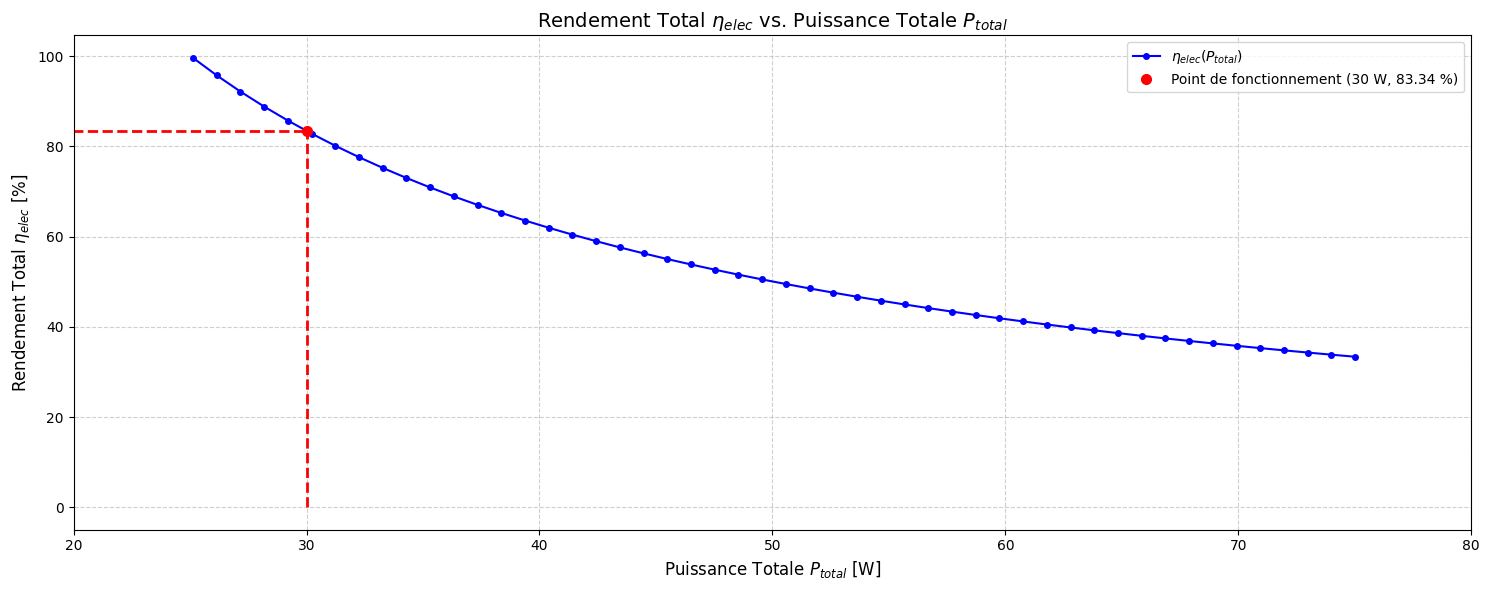

In [5]:
# CELLULE À AJOUTER 1: Rendement Total vs. Puissance Totale

# Fonction utilitaire pour exécuter le modèle et extraire les métriques
def get_performance_metrics(model_instance):
    """Calcule et retourne les métriques clés à partir du modèle."""
    # Le modèle doit être résolu avant d'appeler cette fonction
    model_instance.solve_equations() 
    
    # Récupérer les attributs après résolution
    I_beam = model_instance.I_beam
    V_beam = model_instance.V_beam
    P_discharge = model_instance.P_discharge
    mass_flow = model_instance.mass_flow
    C = model_instance.C
    m_i = model_instance.m_i

    if I_beam == 0.0:
        return 0.0, 0.0, 0.0

    # 1. Calcul de la Poussée et Vitesse de Faisceau
    v_beam = np.sqrt(2 * C['e'] * V_beam / m_i)
    T_thrust = I_beam * m_i * v_beam / C['e']
    
    # 2. Calcul des Puissances
    P_beam = I_beam * V_beam
    P_jet = 0.5 * T_thrust * v_beam
    P_total = P_beam + P_discharge
    eta_elec = P_jet / P_total if P_total > 0 else 0.0
    
    return P_total, eta_elec, T_thrust


# --- Simulation 1: Variation de la Puissance de Décharge (P_discharge) ---

# Paramètres de balayage: P_discharge de 0 W à 50 W
P_discharge_values = np.linspace(0.1, 50, 50) 
P_total_results = []
eta_elec_results = []

# Paramètres du modèle (constants)
const_params = {
    'L_chamber': 0.08, 'A_chamber': 1e-3, 
    'mass_flow': 1e-6, # Débit massique maintenu constant
    'V_beam': 800.0, 
    'd_grids': 1.2e-3, 'tau_optical': 0.65,
    'Te_eV': 5.0, 'ki_coeff': 1e-14
}

for P_disc in P_discharge_values:
    # Instancier le modèle avec la P_discharge courante
    model = GITGlobalModel(P_discharge=P_disc, **const_params)
    
    # Calculer et stocker les résultats
    P_total, eta_elec, _ = get_performance_metrics(model)
    
    P_total_results.append(P_total)
    eta_elec_results.append(eta_elec * 100) # Convertir en pourcentage

# --- Graphique 1: Rendement Total vs. Puissance Totale ---

plt.figure(figsize=(15, 6))

plt.plot(
    P_total_results,
    eta_elec_results,
    marker='o',
    markersize=4,
    linestyle='-',
    color='blue',
    label=r'$\eta_{elec}(P_{total})$'
)

# --- Point de fonctionnement imposé ---
P_target = 30.0
eta_target = 83.34

plt.vlines(P_target, 0, eta_target, colors='red', linestyles='--', linewidth=2)
plt.hlines(eta_target, 0, P_target, colors='red', linestyles='--', linewidth=2)
plt.plot(P_target, eta_target, 'ro', markersize=7,
         label=r'Point de fonctionnement (30 W, 83.34 %)')

plt.title(r'Rendement Total $\eta_{elec}$ vs. Puissance Totale $P_{total}$', fontsize=14)
plt.xlabel(r'Puissance Totale $P_{total}$ [W]', fontsize=12)
plt.ylabel(r'Rendement Total $\eta_{elec}$ [%]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(20,80)
plt.legend()
plt.tight_layout()
plt.show()


Le rendement devrait augmenter en théorie, mais ici on suppose que la puissance du faisceau reste constante (la raison pour laquelle le rendement diminue)

Il faudrait faire en sorte de limiter les pertes aux parois, car ici elles sont surestimées